In [1]:
%load_ext autoreload
%autoreload 2

import os, sys

from pathlib import Path

# # repo root
ROOT = Path().resolve().parent
print(ROOT)
# add src to python path
sys.path.append(str(ROOT / "src"))

import loadder, processor, plotter

import pandas as pd
import numpy as np
# import itertools
# import geopandas as gpd
import matplotlib.pyplot as plt

from matplotlib.transforms import ScaledTranslation
from matplotlib.lines import Line2D
from matplotlib.patches import Patch


ROOT = Path('/Users/Guille/Desktop/india_power/')

CSVS = ROOT / 'air_pollution/csvs'
IMAGES = ROOT / 'images'
OUTPUT = ROOT / 'output_csvs'
INPUTS = ROOT / 'input_data'

/Users/Guille/Desktop/dynamic_update


ModuleNotFoundError: No module named 'loadder'

In [2]:
df_tech_labels = pd.read_csv(CSVS / 'technology_labels.csv') 
df_load_zones  = pd.read_csv(
    INPUTS / "load_zones.csv"
).drop(columns = ['state', 'rps_zone'])

In [3]:
_energy = {}
_energy['scen_labels'] = pd.read_csv(CSVS / f'pollution-scenario_labels-5.csv') 

_energy['capacity'] = loadder.generation_capacity(_energy['scen_labels'])
_energy['dispatch'] = loadder.energy_generation(_energy['scen_labels'])
_energy['capacity'] = processor.group_capacity_technologies(_energy['capacity'], df_tech_labels)
_energy['dispatch'] = processor.group_generation_by_technologies(_energy['dispatch'], df_tech_labels)

CEM_PIERmid_PRMno_SL_PPcoal_NPSHspec_CEWgroup_CAPno_lz /Users/Guille/Desktop/india_power/scenarios/gridpath-india-pollution/cem
CEM_PIERmid_PRMno_SL_Pcoal_NPSHspec_CEWgroup_CAPno_lz /Users/Guille/Desktop/india_power/scenarios/gridpath-india-pollution/cem
CEM_PIERmid_PRMno_SL_Pcoal_NPSHspec_CEWgroup_CAP90_lz /Users/Guille/Desktop/india_power/scenarios/gridpath-india-pollution/cem
CEM_PIERmid_PRMno_SL_PPcoal_NPSHspec_CEWgroup_CAPno_lz all /Users/Guille/Desktop/india_power/scenarios/gridpath-india-pollution/cem
CEM_PIERmid_PRMno_SL_Pcoal_NPSHspec_CEWgroup_CAPno_lz all /Users/Guille/Desktop/india_power/scenarios/gridpath-india-pollution/cem
CEM_PIERmid_PRMno_SL_Pcoal_NPSHspec_CEWgroup_CAP90_lz all /Users/Guille/Desktop/india_power/scenarios/gridpath-india-pollution/cem


In [4]:
# df = _energy['capacity'].groupby(
#     ['period', 'technology', 'scenario']
# ).agg({'capacity_mw': 'sum', 'capacity_mwh': 'sum'}).reset_index(drop = False)

# psh = df.loc[df['technology'] == 'Pumped Storage']
# print(psh)

# psh = df.loc[df['technology'] == 'Nuclear']
# print(psh)

# wind = df.loc[df['technology'] == 'Wind']
# print(wind)

# solar = df.loc[df['technology'] == 'Solar']
# print(solar)

In [5]:
# (actual_periods, 
#  solar_actual_rate, 
#  wind_actual_rate) = loadder.actual_capacity_rates(
#      INPUTS / 'generators/2007-2025_national_capacity.xlsx'
#  )


# periods, solar_rates, wind_rates = processor.vre_capacity(
#     _energy['capacity'], 
#     df_tech_labels,
#     scenario = 'CEM_PIERmid_PRMno_CAPno_lz',
# )

# _fig, _ax = plt.subplots(figsize = (5, 6.5))

# plotter.installation_rate(
#     _fig, _ax,
#     actual_periods,
#     solar_actual_rate, 
#     wind_actual_rate,
#     periods_ = [periods], 
#     solar_rates_ = [solar_rates], 
#     wind_rates_ = [wind_rates],
#     scenarios_ = ['Baseline'],
# )

# # plt.savefig(IMAGES / 'SI-installation_rate.pdf')

# # plt.savefig(IMAGES / 'SI-installation_rate.png', 
# #             bbox_inches = 'tight', 
# #             dpi = 600)

# plt.show()

0.2222222222222222


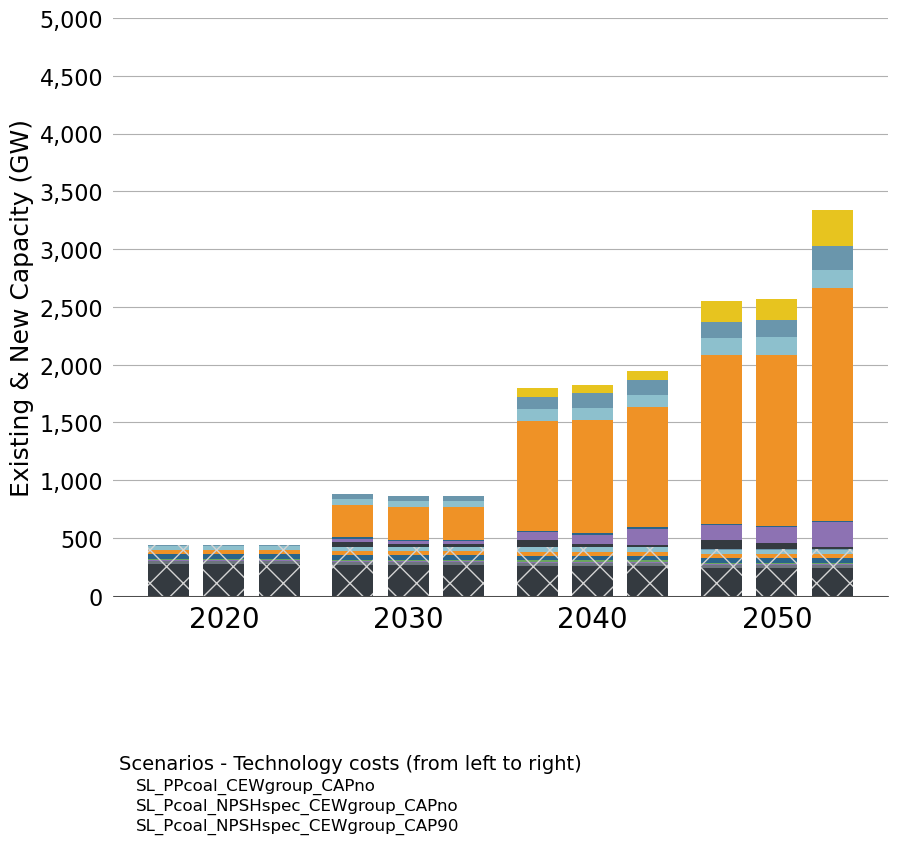

In [6]:
fig, _ax = plt.subplots(figsize=(10, 7.5))

plotter.new_and_existing_generation(
    _ax, 
    _energy['capacity'], 
    _energy['scen_labels'], 
    df_tech_labels, 
    periods_ = [2020, 2030, 2040, 2050],                      
    ylabel = r'Existing & New Capacity (GW)',
    legend = False,
    y_lim_max = 5000,
    y_grid_inc = 500
)

labels_ = _energy['scen_labels']['label']
handles_ = [Patch(visible = False) for _ in labels_]
leg = _ax.legend(
    handles_, 
    labels_,
    loc = (0., -.425),
    title = 'Scenarios - Technology costs (from left to right)',
    frameon = False,
    labelspacing = 0.25,
    title_fontsize = 14,
    handletextpad = -1.,
    ncol = 1,
    prop = {'size': 12}
)

leg._legend_box.align = "left"

plt.savefig(IMAGES / 'cem-new_capacity-pollution-5.pdf',
            bbox_inches = 'tight')

# plt.savefig(IMAGES / 'cem-new_capacity_cap-test.png', 
#             bbox_inches = 'tight',
#             dpi = 600)

plt.show()

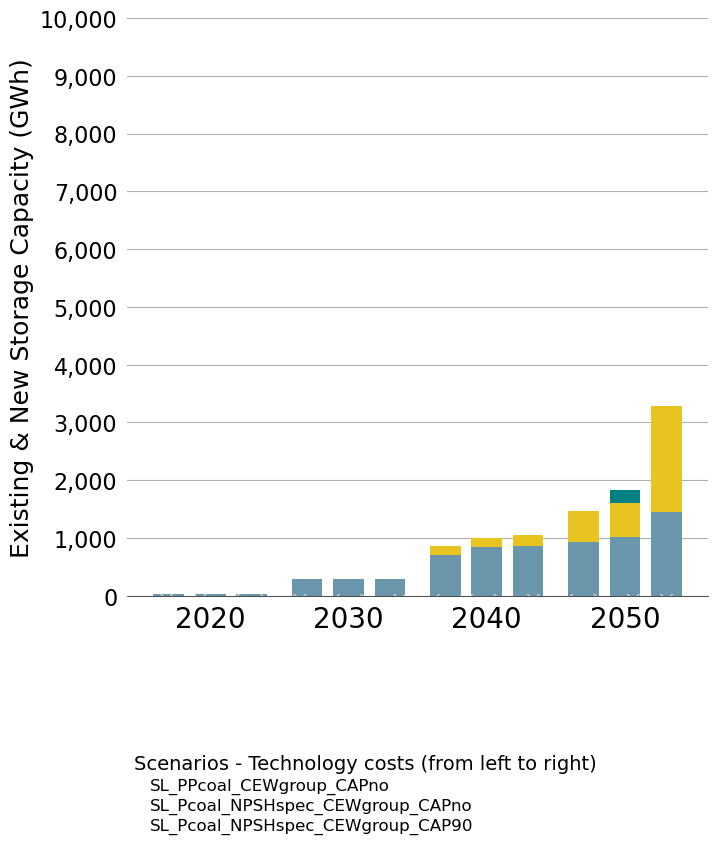

In [7]:
fig, _ax = plt.subplots(figsize=(7.5, 7.5))
    
plotter.new_and_existing_storage(
    _ax, 
    _energy['capacity'], 
    _energy['scen_labels'], 
    df_tech_labels, 
    periods_ = [2020, 2030, 2040, 2050],                        
    ylabel = r'Existing & New Storage Capacity (GWh)',
    legend = False,
    y_lim_max = 10000,
    y_grid_inc = 1000
)

labels_ = _energy['scen_labels']['label']
handles_ = [Patch(visible=False) for _ in labels_]
leg = _ax.legend(
    handles_, 
    labels_, 
    loc = (0., -.425),
    title = 'Scenarios - Technology costs (from left to right)',
    frameon = False,
    labelspacing = 0.25,
    title_fontsize = 14,
    handletextpad = -1.,
    ncol = 1,
    prop = {'size': 12}
)

leg._legend_box.align = "left"

plt.savefig(IMAGES / 'cem-stor_capacity-pollution-4.pdf',
            bbox_inches = 'tight')

# plt.savefig(IMAGES / 'cem-stor_capacity_cap-test.png', 
#             bbox_inches = 'tight',
#             dpi = 600)

plt.show()

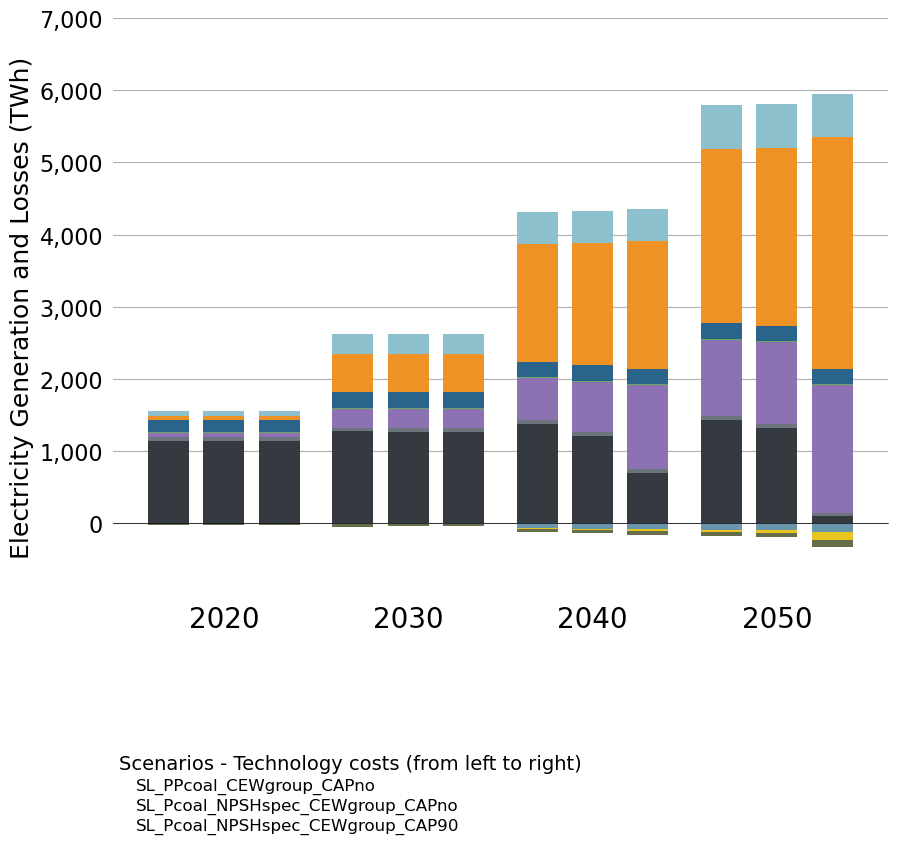

In [8]:
fig, _ax = plt.subplots(figsize=(10, 7.5))
    
plotter.energy_generation(
    _ax, 
    _energy['dispatch'], 
    _energy['scen_labels'], 
    df_tech_labels, 
    periods_ = [2020, 2030, 2040, 2050],
    ylabel = r'Electricity Generation and Losses (TWh)', 
    legend = True, 
    y_lim_max = 7000,
    y_lim_min = -1000,
    y_grid_inc = 1000
)

labels_ = _energy['scen_labels']['label']
handles_ = [Patch(visible=False) for _ in labels_]
leg = _ax.legend(
    handles_, 
    labels_, 
    loc = (0., -.425),
    title = 'Scenarios - Technology costs (from left to right)',
    frameon = False,
    labelspacing = 0.25,
    title_fontsize = 14,
    handletextpad = -1.,
    ncol = 1,
    prop = {'size': 12}
)

leg._legend_box.align = "left"

plt.savefig(IMAGES / 'cem-gen_capacity-pollution-4.pdf',
            bbox_inches = 'tight')

# plt.savefig(IMAGES / 'cem-gen_capacity_cap-test.png', 
#             bbox_inches = 'tight',
#             dpi = 600)

plt.show()

In [9]:
_system = {}
_system['scen_labels'] = pd.read_csv(CSVS / f'pollution-scenario_labels-5.csv') 

df_cost = loadder.system_cost(_system['scen_labels'])
df_clean = loadder.clean_energy(_system['scen_labels'])
df_demand = loadder.demand(_system['scen_labels'])
df_emission = loadder.carbon_emissions(_system['scen_labels'])

_system['emissions'] = df_emission.groupby(
    ['period', 'scenario']
).agg({'carbon_emissions_tons': 'sum'}).reset_index(drop = False)

_system['system_cost'] = df_cost.groupby(
    ['period', 'scenario']
).agg({'variable_cost': 'sum',
       'fixed_cost': 'sum'}).reset_index(drop = False)

_system['demand'] = df_demand.groupby(
    ['period', 'scenario']
).agg({'load_mw': 'sum'}).reset_index(drop = False)

_system['demand']['load_zone'] = 'all'
_system['demand']['load_zone'] = 'all'
_system['emissions']['load_zone'] = 'all'
_system['system_cost']['load_zone'] = 'all'

# Add fixed cost of specified transmission capacity exogenously
_system['system_cost']['fixed_cost'] += 5.79e9

/Users/Guille/Desktop/india_power/scenarios/gridpath-india-pollution/cem/CEM_PIERmid_PRMno_SL_PPcoal_NPSHspec_CEWgroup_CAPno_lz
/Users/Guille/Desktop/india_power/scenarios/gridpath-india-pollution/cem/CEM_PIERmid_PRMno_SL_Pcoal_NPSHspec_CEWgroup_CAPno_lz
/Users/Guille/Desktop/india_power/scenarios/gridpath-india-pollution/cem/CEM_PIERmid_PRMno_SL_Pcoal_NPSHspec_CEWgroup_CAP90_lz
CEM_PIERmid_PRMno_SL_PPcoal_NPSHspec_CEWgroup_CAPno_lz /Users/Guille/Desktop/india_power/scenarios/gridpath-india-pollution/cem
CEM_PIERmid_PRMno_SL_Pcoal_NPSHspec_CEWgroup_CAPno_lz /Users/Guille/Desktop/india_power/scenarios/gridpath-india-pollution/cem
CEM_PIERmid_PRMno_SL_Pcoal_NPSHspec_CEWgroup_CAP90_lz /Users/Guille/Desktop/india_power/scenarios/gridpath-india-pollution/cem
CEM_PIERmid_PRMno_SL_PPcoal_NPSHspec_CEWgroup_CAPno_lz /Users/Guille/Desktop/india_power/scenarios/gridpath-india-pollution/cem
CEM_PIERmid_PRMno_SL_Pcoal_NPSHspec_CEWgroup_CAPno_lz /Users/Guille/Desktop/india_power/scenarios/gridpath-i

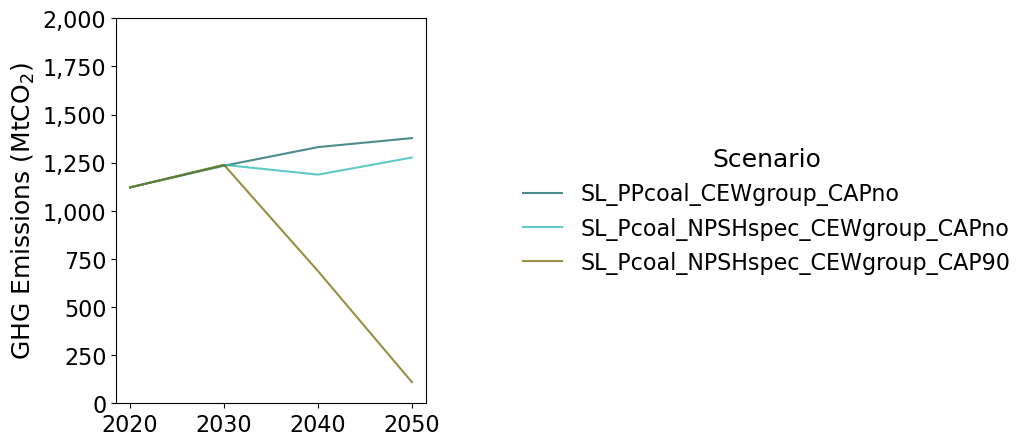

In [10]:
# Plot GHG emissions for the different scenarios
fig, _ax = plt.subplots(figsize = (4, 5))

plotter.carbon_emissions(
    _ax, 
    _system['emissions'], 
    _system['scen_labels'], 
    periods_ = [2020, 2030, 2040, 2050], 
    y_min = 0,
    y_max = 2000,
    legend = True
)

plt.savefig(IMAGES / 'cem-emissions-pollution-5.pdf', 
            bbox_inches = 'tight')

# plt.savefig(IMAGES / 'cem-emissions_cap.png',
#             bbox_inches = 'tight',
#             dpi = 600)

plt.show()

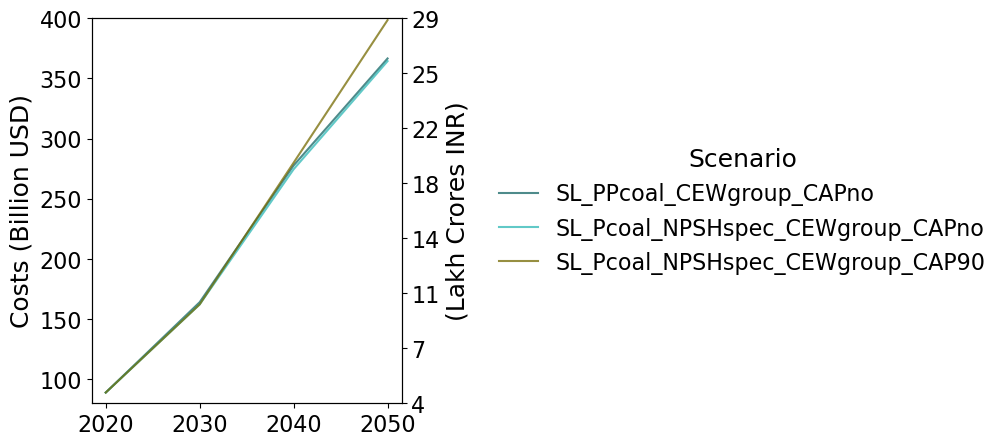

In [11]:
# Plot system cost for the different scenarios
fig, _ax = plt.subplots(figsize = (4, 5))

plotter.system_cost(
    _ax, 
    _system['system_cost'], 
    _system['scen_labels'], 
    periods_ = [2020, 2030, 2040, 2050],
    y_min = 80,
    y_max = 400,
    legend = True
)

plt.savefig(IMAGES / 'cem-system_cost-pollution-5.pdf',
            bbox_inches = 'tight')

# plt.savefig(IMAGES / 'cem-system_cost_prm.png',
#             bbox_inches = 'tight',
#             dpi = 600)

plt.show()

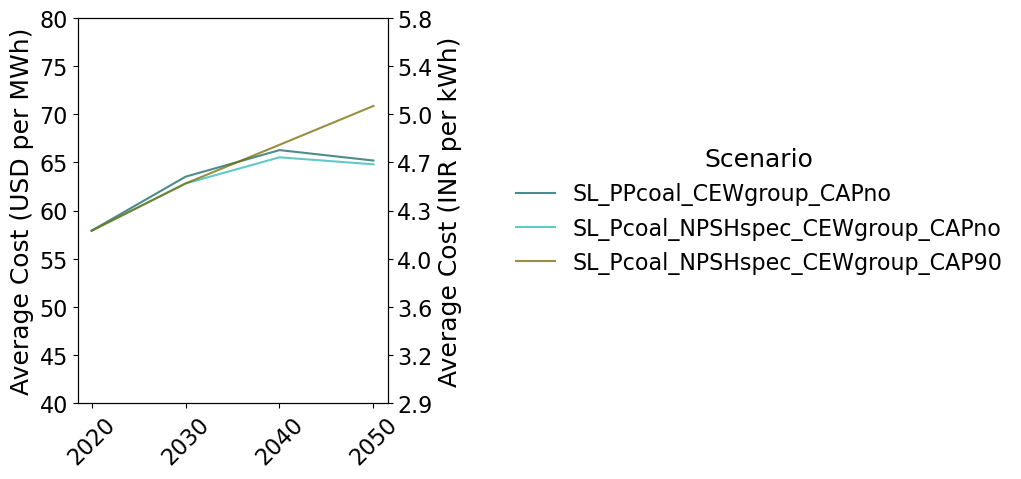

In [12]:
# Plot levelized cost of electricity for different scenarios
fig, _ax = plt.subplots(figsize = (4, 5))

plotter.electricity_cost(
    _ax, 
    _system['system_cost'], 
    _system['demand'], 
    _system['scen_labels'],   
    periods_ = [2020, 2030, 2040, 2050],             
    y_min = 40,
    y_max = 80,
    legend = True
)

plt.savefig(IMAGES / 'cem-electricity_cost-pollution-5.pdf',
            bbox_inches = 'tight')

# plt.savefig(IMAGES / 'cem-electricity_cost_cap.png',
#             bbox_inches = 'tight',
#             dpi = 600)

plt.show()